# 02 — Phase 1: GQA Only Baseline

**配置**: Qwen2.5-1.5B-Instruct + HuggingFace DynamicCache (FP16)

这是最基本的 baseline：
- **GQA**: 12 query heads, 2 KV heads → KV Cache 比 MHA 小 6×
- **DynamicCache**: 连续 FP16 张量，逐步 concat 扩展
- 没有量化，没有分页

### 关键目标
1. 记录各指标基线值 (TTFT, TPOT, peak memory)
2. **找到 OOM 阈值**：context 多长会炸掉 10-12 GB 统一内存
3. 分离 **模型权重占用** vs **KV Cache 占用**

In [1]:
import sys, gc, torch
sys.path.insert(0, '..')

from src.metrics import (
    measure_generation, run_benchmark, find_oom_threshold,
    print_memory_budget, JETSON_USABLE_GB,
)
from src.dataset_utils import load_prompts

In [2]:

from src.jetson_utils import load_model_safe, aggressive_cleanup

MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct"
FALLBACK_NAME = "unsloth/Llama-3.2-3B-Instruct"
DEVICE = "cuda"

# Safe loading: checks free memory, falls back to lighter model, uses low_cpu_mem_usage
model, tokenizer = load_model_safe(
    MODEL_NAME,
    fallback_name=FALLBACK_NAME,
    device=DEVICE,
)

# 分离显示模型权重 vs 可用空间
budget = print_memory_budget(model, DEVICE)


/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/venv/lib/python3.12/site-packages/transformers/utils/hub.py:105: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:08<00:00,  4.21s/it]


✓ Loaded unsloth/Llama-3.2-3B-Instruct (torch.float16)  GPU mem: 5.98 GB
Jetson Orin NX Memory Budget
Total physical    : 16,384 MB (16.0 GB)
Usable (after OS) : 11,264 MB (11.0 GB)
Model weights     : 6,128 MB
CUDA overhead     : ~500 MB
>>> KV Cache budget: 4,636 MB (4.5 GB)
Currently allocated: 6,128 MB
Currently reserved : 6,882 MB


In [3]:
# GQA 架构确认
cfg = model.config
print(f"num_attention_heads  : {cfg.num_attention_heads}")
print(f"num_key_value_heads  : {cfg.num_key_value_heads}")
print(f"num_hidden_layers    : {cfg.num_hidden_layers}")
print(f"hidden_size          : {cfg.hidden_size}")
head_dim = cfg.hidden_size // cfg.num_attention_heads
print(f"head_dim             : {head_dim}")
print(f"GQA ratio            : {cfg.num_attention_heads // cfg.num_key_value_heads}:1")
print(f"\n→ 每个 token 的 KV Cache (FP16):")
kv_per_token = 2 * cfg.num_hidden_layers * cfg.num_key_value_heads * head_dim * 2
print(f"  {kv_per_token:,} bytes = {kv_per_token/1024:.1f} KB/token")

num_attention_heads  : 24
num_key_value_heads  : 8
num_hidden_layers    : 28
hidden_size          : 3072
head_dim             : 128
GQA ratio            : 3:1

→ 每个 token 的 KV Cache (FP16):
  114,688 bytes = 112.0 KB/token


---
## OOM 阈值探测

在 10-12 GB 统一内存下，找出 GQA-only baseline 能支撑的最大 context length。

In [ ]:
# OOM 阈值探测
import json

print("探测 OOM 阈值 (context length → peak memory)...")
oom_result = None

try:
    oom_result = find_oom_threshold(
        model, tokenizer,
     # 逐步探测更安全。。
        context_lengths=[256, 512, 1024, 1536, 2048, 3072, 4096],
        max_new_tokens=8,
        cache_factory=None,  # default DynamicCache
        memory_headroom_mb=2500,
    )

    print(f"\n最大安全长度: {oom_result['max_safe_length']}")
    print(f"OOM 发生在  : {oom_result['oom_length']}")
    print(f"\n详细结果:")
    for r in oom_result['results']:
        status = r['status']
        if status == 'ok':
            print(f"  ctx={r['context_length']:>6}  peak={r['peak_memory_mb']:>7.0f} MB  "
                  f"util={r['utilization']*100:>5.1f}%")
        else:
            print(f"  ctx={r['context_length']:>6}  → {status}")

    # 成功完成后落盘，便于 kernel 重启后继续可视化
    with open('../results/oom_result_gqa.json', 'w') as f:
        json.dump(oom_result, f, indent=2)
    print("\nSaved → results/oom_result_gqa.json")
except Exception as e:
    print(f"\nOOM 探测未完成: {e}")
    print("提示: 若发生 kernel 重启，请先重新运行本单元，或检查 results/oom_result_gqa.json 是否已存在。")

In [4]:
%pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple


Using pip 25.0.1 from /opt/venv/lib/python3.12/site-packages/pip (python 3.12)
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


Loaded oom_result from results/oom_result_gqa.json


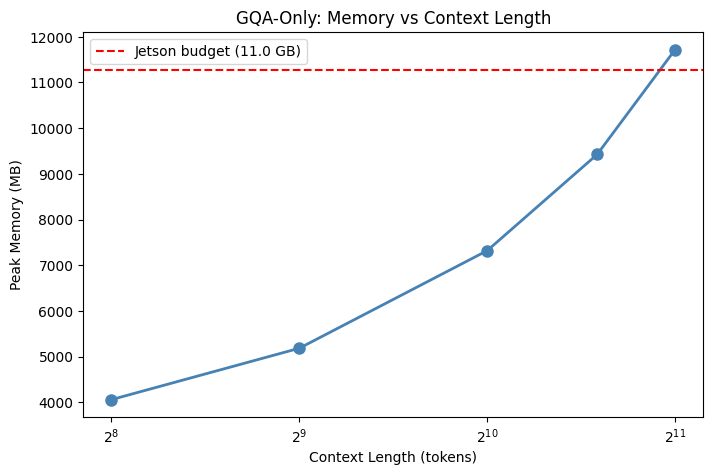

In [5]:
# OOM 阈值可视化
import json
import matplotlib.pyplot as plt

if 'oom_result' not in dir() or oom_result is None:
    try:
        with open('../results/oom_result_gqa.json') as f:
            oom_result = json.load(f)
        print("Loaded oom_result from results/oom_result_gqa.json")
    except FileNotFoundError:
        oom_result = None

if oom_result is None:
    print("⚠️ 未找到 oom_result。请先运行上一单元完成 OOM 探测。")
else:
    ok_results = [r for r in oom_result['results'] if r['status'] == 'ok']
    ctx_lens = [r['context_length'] for r in ok_results]
    peak_mems = [r['peak_memory_mb'] for r in ok_results]

    if len(ctx_lens) == 0:
        print("⚠️ 没有可视化数据（全部失败或被跳过）。")
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(ctx_lens, peak_mems, 'o-', color='steelblue', linewidth=2, markersize=8)
        ax.axhline(y=JETSON_USABLE_GB * 1024, color='red', linestyle='--',
                   label=f'Jetson budget ({JETSON_USABLE_GB} GB)')
        if oom_result['oom_length']:
            ax.axvline(x=oom_result['oom_length'], color='darkred', linestyle=':',
                       label=f'OOM @ {oom_result["oom_length"]}')
        ax.set_xlabel('Context Length (tokens)')
        ax.set_ylabel('Peak Memory (MB)')
        ax.set_title('GQA-Only: Memory vs Context Length')
        ax.legend()
        ax.set_xscale('log', base=2)

---
## EHR Benchmark（Selective Retention）— GQA Only Baseline

使用 `get_selective_prompts()` 生成的 EHR 数据做基准测试。
每条 prompt 包含：
- `prompt` — 喂给模型的完整文本（用于测 TTFT / TPOT / 内存）
- `reference_answer` — ground truth 答案（用于测 PPL 质量退化）
- `question` — 原始问题
- `num_events_original` / `num_events_retained` — 事件筛选前后数量

In [6]:
prompts = load_prompts('../results/ehr_prompts_llama3.2.json')
print(f"Loaded {len(prompts)} prompts")

Loaded 50 prompts


In [7]:
# 单样本快速测试 (先 warmup 避免 CUDA 编译开销)
print("Warmup...")
_ = measure_generation(model, tokenizer, prompts[0]['prompt'], max_new_tokens=8)
torch.cuda.empty_cache()

m = measure_generation(model, tokenizer, prompts[0]['prompt'], max_new_tokens=256)
print(f"TTFT           : {m.ttft_ms:.1f} ms")
print(f"TPOT           : {m.tpot_ms:.1f} ms")
print(f"Model weights  : {m.model_weight_mb:.0f} MB")
print(f"KV Cache       : {m.kv_cache_memory_mb:.1f} MB")
print(f"Peak memory    : {m.peak_memory_mb:.0f} MB")
print(f"Memory util    : {m.memory_utilization*100:.1f}% of {JETSON_USABLE_GB}GB budget")
print(f"Fragmentation  : {m.memory_fragmentation:.3f}")
print(f"Tokens         : {m.num_input_tokens} in → {m.num_output_tokens} out")
print(f"\nGenerated: {m.generated_text[:200]}...")

Warmup...
TTFT           : 1570.7 ms
TPOT           : 215.3 ms
Model weights  : 6136 MB
KV Cache       : 239.3 MB
Peak memory    : 6383 MB
Memory util    : 56.7% of 11.0GB budget
Fragmentation  : 0.094
Tokens         : 676 in → 256 out

Generated: To answer this question, I will follow a step-by-step approach to analyze the provided longitudinal electronic health record (EHR) and identify the first recorded diagnosis for the patient.

1. **Init...


In [8]:
# 完整基准测试
results_gqa = run_benchmark(
    model, tokenizer, prompts,
    cache_factory=None,     # HF DynamicCache
    max_new_tokens=256,
    warmup_runs=2, num_runs=3,
)
print(f"Completed {len(results_gqa)} samples")

Running 2 warmup cycles...
Warmup complete. Starting benchmark...

  [1/50] ttft=1570ms  tpot=215.3ms  peak=6383MB  out=256tok
  [2/50] ttft=1566ms  tpot=215.2ms  peak=6382MB  out=256tok
  [3/50] ttft=1567ms  tpot=215.2ms  peak=6383MB  out=256tok
  [4/50] ttft=1561ms  tpot=214.1ms  peak=6378MB  out=230tok
  [5/50] ttft=1553ms  tpot=214.5ms  peak=6377MB  out=256tok
  [6/50] ttft=1555ms  tpot=214.6ms  peak=6378MB  out=256tok
  [7/50] ttft=1557ms  tpot=214.7ms  peak=6379MB  out=256tok
  [8/50] ttft=1556ms  tpot=214.6ms  peak=6378MB  out=256tok
  [9/50] ttft=1560ms  tpot=214.7ms  peak=6378MB  out=256tok
  [10/50] ttft=1555ms  tpot=214.4ms  peak=6377MB  out=256tok
  [11/50] ttft=1550ms  tpot=214.3ms  peak=6376MB  out=256tok
  [12/50] ttft=1552ms  tpot=214.4ms  peak=6377MB  out=256tok
  [13/50] ttft=1550ms  tpot=214.2ms  peak=6375MB  out=256tok
  [14/50] ttft=1546ms  tpot=214.1ms  peak=6374MB  out=256tok
  [15/50] ttft=1547ms  tpot=214.1ms  peak=6374MB  out=256tok
  [16/50] ttft=1565ms  tpot

In [9]:
import pandas as pd

df = pd.DataFrame(results_gqa)
df['config'] = 'GQA_only'
df.to_csv('../results/baseline_gqa.csv', index=False)

cols = ['ttft_ms', 'tpot_ms', 'peak_memory_mb', 'model_weight_mb',
        'kv_cache_memory_mb', 'memory_utilization']
print(df[cols].describe().round(1))

       ttft_ms  tpot_ms  peak_memory_mb  model_weight_mb  kv_cache_memory_mb  \
count     50.0     50.0            50.0             50.0                50.0   
mean    1547.8    214.4          6376.8           6136.0               232.8   
std       33.5      0.6             3.7              0.0                 3.6   
min     1387.5    212.3          6369.7           6136.0               225.9   
25%     1547.4    214.1          6373.8           6136.0               229.9   
50%     1554.0    214.4          6377.2           6136.0               233.3   
75%     1560.8    214.8          6380.1           6136.0               236.1   
max     1570.1    215.3          6383.4           6136.0               239.3   

       memory_utilization  
count                50.0  
mean                  0.6  
std                   0.0  
min                   0.6  
25%                   0.6  
50%                   0.6  
75%                   0.6  
max                   0.6  


---
## PPL 评估（质量基线）

记录全精度基线的 Perplexity，后续对比量化后的退化。

In [10]:
from src.perplexity import compute_perplexity
from src.dataset_utils import load_prompts

# 安全加载：如果前面的 cell 没运行，重新加载 prompts
if 'prompts' not in dir() or not prompts:
    prompts = load_prompts('../results/ehr_prompts.json')
    print(f"Reloaded {len(prompts)} prompts")

# 用 EHR QA 的 reference_answer 作为评估文本
eval_texts = [p['reference_answer'] for p in prompts[:20] if p.get('reference_answer')]
print(f"PPL evaluation on {len(eval_texts)} texts...")

ppl_baseline = compute_perplexity(model, tokenizer, eval_texts, max_length=512)
print(f"\nBaseline PPL : {ppl_baseline['ppl']:.2f}")
print(f"Avg loss     : {ppl_baseline['avg_loss']:.4f}")
print(f"Tokens eval  : {ppl_baseline['num_tokens']}")

PPL evaluation on 20 texts...


Computing PPL: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.13it/s]


Baseline PPL : 45.71
Avg loss     : 3.8222
Tokens eval  : 253


In [11]:
# 保存 PPL 结果（JSON + CSV 双格式）
import json

ppl_results = {'GQA_only': ppl_baseline}
with open('../results/ppl_results.json', 'w') as f:
    json.dump(ppl_results, f, indent=2)

ppl_df = pd.DataFrame([{
    'config': 'GQA_only',
    'ppl': ppl_baseline['ppl'],
    'avg_loss': ppl_baseline['avg_loss'],
    'num_tokens': ppl_baseline['num_tokens'],
}])
ppl_df.to_csv('../results/ppl_gqa_only.csv', index=False)

print("Saved → results/ppl_results.json + results/ppl_gqa_only.csv")

Saved → results/ppl_results.json + results/ppl_gqa_only.csv


In [12]:
# 释放模型（后续 notebook 重新加载）
del model
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / (1024**2):.0f} MB")

GPU memory after cleanup: 8 MB
